:::{admonition} Do this exercise yourself!
:class: important

This notebook is an exercise for practicing using plenoptic. You should work through it on your own, either by clicking on one of the following buttons or opening up a new notebook on your own machine and following along.

Regardless of which you choose, you should keep this page open for reference, as the links to other pages in the documentation (and some images) are broken in the downloaded and binder notebooks.

If you would like to install everything required to run this notebooks on your local machine, run `pip install plenoptic[nb]`. See [](install-doc) and [](jupyter-doc) for more details.

Download the executed notebook: **{nb-download}`4_torchvision.ipynb`**!

Run it in your browser: **{binder}`4_torchvision.ipynb`**!

:::


# Synthesizing Deep Net Model Metamers

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

plenoptic is compatible with any model written in pytorch, including deep neural networks from the model zoos {external+torchvision:ref}`TorchVision <models>` and {external+timm:doc}`timm <models>`. In this exercise, we'll grab ResNet50 from torchvision and show how to generate metamers for one of its intermediate representations, as done in {cite:alp}`Feather2023-model-metam`.

This tutorial covers similar ground as [](feather2023-resnet50), but goes into a little less detail. View that page and [](deep_nets) for more details.

:::{attention}
It is recommended that you first work through the [](simple-metamer) exercise before this one! The optimization procedure here is a bit more complex and takes longer.
:::

In [1]:
# needed for the plotting/animating:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

import plenoptic as po

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The default value of 6000 for MAX_ITER here will lead to a reasonable metamer, but
# might take too long if you don't have a GPU. If synthesis is taking a long time on
# your machine, set this to a lower value.
MAX_ITER = int(os.environ.get("MAX_ITER", 6000))

When synthesizing model metamers for convolutional neural networks, researchers often pick a specific layer whose output they want to match. If we look at [Feather et al. 2023](https://mcdermottlab.mit.edu/papers/Feather_etal_2023_deep_metamers.pdf) Figure 2e, we can see an interesting progression in layers 2 through 4: the layer 2 metamer looks almost identical to the target image, the layer 3 metamer starts to add RGB noise, and the layer 4 is almost completely unidentifiable, looking almost completely like random RGB noise. We'll pick layer 3 from now, and you're encouraged to try the other layers!

## Use a model from torchvision

First, let's download the model weights for ResNet50 trained on [ImageNet-1K](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K) and initialize the `torchvision` model.

In [2]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)

Next, we ensure that our model is in evaluation mode. Many models, including ResNet50, behave differently when in training and evaluation mode. In plenoptic, models are fixed and so we want the evaluation behavior:

In [3]:
deepnet.eval();

Next, we grab the preprocessing transform from the model. As the [torchvision docs](https://docs.pytorch.org/vision/stable/models.html#using-the-pre-trained-models) explain it (quoting version `0.27`):

> Before using the pre-trained models, one must preprocess the image (resize with right resolution/interpolation, apply inference transforms, rescale the values etc). There is no standard way to do this as it depends on how a given model was trained. It can vary across model families, variants or even weight versions. Using the correct preprocessing method is critical and failing to do so may lead to decreased accuracy or incorrect outputs.

For models trained on ImageNet, this preprocessing consists of two steps: resizing to a height and width of 224 pixels and normalizing the color channels (subtracting means and dividing by standard deviations). Following Feather et al. 2023 we recommend including the normalization step in the model for metamer synthesis, but handling the image resizing externally. Below, we set up the normalization transform, and we resize the image in the [next section](torchvision-prepare-image).

In [4]:
transform = weights.transforms()
print(transform)
norm = torchvision.transforms.Normalize(transform.mean, transform.std)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


:::{admonition} What happens if the image resizing is included in the plenoptic model?
:class: dropdown question

If you include the image resizing in the plenoptic model when synthesizing a model metamer, you will clearly see the effect: since the transform crops out the center of the image, the model is completely insensitive to the border, and so it will be unchanged from initialization.

If you're curious, try it out and see! (Just pass `transform` instead of `norm` to {class}`~plenoptic.models.DeepNetFeatures` model in the block below.)

:::

Finally, we'll pass our neural network, target layer, and preprocessing transform to {class}`~plenoptic.models.DeepNetFeatures`, moving it to our specified device and removing the gradient from all learnable parameters (as models in plenoptic [are fixed](remove-grad-doc)):

In [5]:
model = po.models.DeepNetFeatures(deepnet, "layer3", norm)
model.to(DEVICE)
po.remove_grad(model)

(torchvision-prepare-image)=
## Preparing the image

Now, let's prepare the image. The input image needs to be an RGB image with a height and width of 224 pixels. It should probably also be like those found in ImageNet: a single object in the center of the frame that belongs to one of the [image classes](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). We'll use one of the famous [monkey selfies](https://en.wikipedia.org/wiki/Monkey_selfie_copyright_dispute), and resize it appropriately:

In [6]:
img = po.data.macaque().to(DEVICE)
# here we downsample the original image by a factor of 4 and then lop off the bottom.
# that way, when we take the central 224 pixels in the following block, we end up with a
# decent image.
img = po.process.blur_downsample(img, 2)[..., :-59, :]

As discussed above, models trained on ImageNet should be passed an image of size 224 by 224. We'll use plenoptic's {func}`plenoptic.process.center_crop` to do so, grabbing the required size directly from the model's associated `transform`;

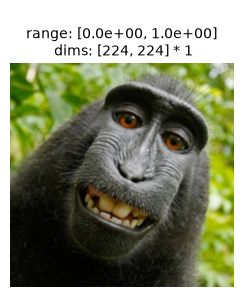

In [7]:
img = po.process.center_crop(img, transform.crop_size[0])
po.plot.imshow(img, as_rgb=True);

## Synthesize model metamers!

Now we can use the above like any other model we've used so far, though note that we need to tweak some of the optimization hyperparameters. Here, like in the Feather et al. paper, we find better results if we gradually decrease the learning rate over synthesis (using {external+torch:class}`~torch.optim.lr_scheduler.StepLR` to halve the learning rate every 3000 steps). We also use the standard version of {external+torch:class}`~torch.optim.Adam`, rather than the AMSGrad variant (which is the default in plenoptic).

In [8]:
met = po.Metamer(img, model)
scheduler = torch.optim.lr_scheduler.StepLR
scheduler_kwargs = {"step_size": 3000, "gamma": 0.5}
met.setup(
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)
# by setting stop_iters_to_check=max_iter, we ensure it keeps going through
# all iterations
met.synthesize(max_iter=MAX_ITER, stop_iters_to_check=MAX_ITER, store_progress=120)

  0%|          | 0/6000 [00:00<?, ?it/s]

And look at the output:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00071241776..0.9996015].


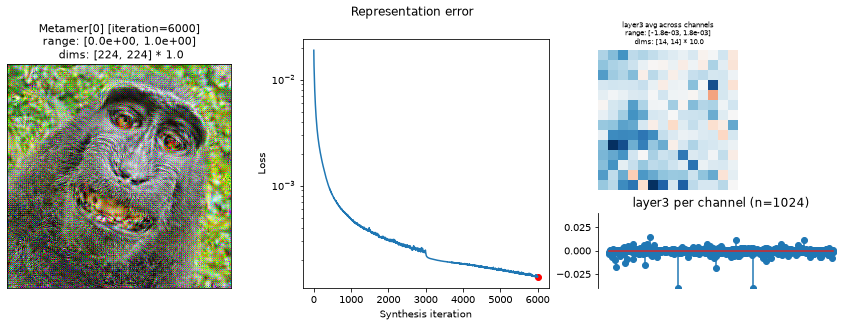

In [9]:
po.plot.synthesis_status(met, figsize=(15, 4.5));

In the above plots, we can see the metamer in the leftmost subplot, the loss over synthesis iterations in the middle, and the representation error on the right:

- Our metamer match the results discussed earlier in this notebook: as a layer 3 metamer, it looks like the original image with some RGB noise added.
- We can see that the optimization performed reasonably well: the loss decreased gradually over synthesis. If you were using these stimuli in an experiment, it may be worth continuing a bit more to get the loss even lower, but this example demonstrates the point.
- The representation error plot has two subplots. The first plots the average across channel (the average spatial representation), while the second averages across space to get a per-channel average representation. We can see that, while there's variation across both channels and space, there's not an obvious outlier whose error we have been unable to constrain.

As before, we can animate to see this process over time:

In [10]:
po.plot.synthesis_animate(met, figsize=(15, 4.5))

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_main/lib/python3.12/site-packages/plenoptic/plot/synthesis.py:2065: UserWarning: 50 frames of saved metamer clipped: Clipping input data to the valid range for imshow with RGB data ([0..1] for floats). To avoid clipping, use process_image argument.
  warnings.warn(warning_msg)


## Understand the output

The authors of Feather et al., 2023 used two additional checks to verify that metamer synthesis had succeeded (quotes from "Results > Metamer optimization" section, pdf page 5):
- "the metamer had to result in the same classification decision by the model as the reference stimulus"
- "measures of the match between the activations for the natural reference stimulus and its model metamer at the matched stage had to be much higher than would be expected by chance, as quantified with a null distribution". The authors used three measures here: Pearson and Spearman correlations and signal-to-noise ratio. We could compute those measures, but without the null distribution, they're difficult to interpret. So we just note that one should do something similar in order to verify synthesis has succeeded.

The following cell shows how to compute the image categories:

In [11]:
imagenet_categories = np.asarray(weights.meta["categories"])
deepnet.to(DEVICE)


def get_category(image):
    image_cat = po.to_numpy(
        torch.nn.functional.softmax(deepnet(norm(image)), dim=1).squeeze()
    )
    return imagenet_categories[image_cat.argmax()]


print(f"Original image category: {get_category(met.image)}")
print(f"Model metamer category: {get_category(met.metamer)}")

Original image category: guenon
Model metamer category: guenon


## Different layer

Look at figure 2e in {cite:alp}`Feather2023-model-metam` and pick another layer to target. The hyperparameters we picked should work reasonably well for layers 2 and 4, but others have not been tested. Look at the output of {func}`~plenoptic.plot.synthesis_status` and tweak the hyperparameters as necessary to get the loss as low as possible!

:::{admonition} How do I know what layers I can use?
:class: dropdown question

In this case, you can pick any of the `"layerN"` used in Feather et al., 2023. You can also view possible layer names with {external+torchvision:func}`torchvision.models.feature_extraction.get_graph_node_names`. (For more details on the node naming conventions, please see the {external+torchvision:ref}`About Node Names <about-node-names>` heading in the {external+torchvision:doc}`torchvision documentation <feature_extraction>`.)

```python
from torchvision.models import feature_extraction
# this function returns two lists, the first for training mode, the second for eval mode
feature_extraction.get_graph_node_names(deepnet)[1]
```
:::

In [ ]:
target_layer = ...  # WRITE SOMETHING HERE
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)
model.to(DEVICE)

met = po.Metamer(img, model)
met.setup(
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)
# by setting stop_iters_to_check=max_iter, we ensure it keeps going through
# all iterations
met.synthesize(max_iter=MAX_ITER, stop_iters_to_check=MAX_ITER, store_progress=120)
po.plot.synthesis_status(met, figsize=(15, 4.5));

You can also specify multiple layers (as a list of strings, e.g., `["layer2", "layer3"]`) to match multiple layers at once!

## Different target image

Try using a different target image than the one of macaque above and running metamer synthesis until completion:

:::{admonition} Loading other images
:class: hint

Try one of the other {ref}`included images <images-api>` or use {func}`plenoptic.load_images` to load one from disk.

:::

Don't forget to ensure the image has a height and width of 224! There are many ways you can do this, refer back to [](torchvision-prepare-image) for some useful functions included in plenoptic.

In [ ]:
new_img = ...  # WRITE SOMETHING NEW HERE
# USE SOME COMBINATION OF DOWNSAMPLING AND/OR CROPPING TO CHANGE THE HEIGHT TO 224 x 224
assert new_image.shape[-2:] == (224, 224), "Image is the wrong shape!"
new_img = new_img.to(DEVICE)
met = po.Metamer(img, model)
met.setup(
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)
# by setting stop_iters_to_check=max_iter, we ensure it keeps going through
# all iterations
met.synthesize(max_iter=MAX_ITER, stop_iters_to_check=MAX_ITER, store_progress=120)
po.plot.synthesis_status(met, figsize=(15, 4.5));

And maybe animate to see what synthesis looks like?

In [ ]:
po.plot.synthesis_animate(met, figsize=(15, 4.5))

## Different initial image

While Feather et al., 2023 initialized from a patch of white noise, it can be interesting to start from a different image as well. Using one of the same tools as above for loading another image, initialize metamer synthesis from another starting point and run it to completion.

As in the previous section, don't forget to ensure this image has a height and width of 224! There are many ways you can do this, refer back to [](torchvision-prepare-image) for some useful functions included in plenoptic.

In [ ]:
met = po.Metamer(img, model)
met.setup(
    initial_image=...,  # WRITE SOMETHING HERE
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)
assert met.metamer.shape == met.image.shape, "Initial image is the wrong shape!"
met.synthesize(max_iter=MAX_ITER, stop_iters_to_check=MAX_ITER, store_progress=120)
po.plot.synthesis_status(met, figsize=(15, 4.5));

And maybe animate to see what synthesis looks like?

In [ ]:
po.plot.synthesis_animate(met, figsize=(15, 4.5))

## Different DeepNet

This setup works for any torchvision model! Pick another [model with pre-trained weights](https://docs.pytorch.org/vision/main/models.html#classification) and a layer to target, and synthesize some model metamers!

In [ ]:
weights = ...  # WRITE SOMETHING HERE!
deepnet = ...  # WRITE SOMETHING HERE!
deepnet.eval()

Don't forget to grab their transform! How exactly this looks will depend on the model, but remember that we recommend any image-resizing transforms be handled *externally* and everything else be part of the metamer model.

In [ ]:
# This should work for any ImageNet-trained model, but you'll have to do something else
# for other models
transform = weights.transforms()
print(transform)
norm = torchvision.transforms.Normalize(transform.mean, transform.std)

Now, specify the intermediate layer you want to match and initialize the plenoptic model!

In [ ]:
target_layer = ...  # WRITE SOMETHING HERE
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)
model.to(DEVICE)

And finally, instantiate the metamer and run synthesis. Note that the arguments to {meth}`~plenoptic.Metamer.setup` will almost certainly need to be changed, but we've repeated the ones used for ResNet50 as a starting point. You may also need to change the loss function, see [](3_textures) for an example of changing this, and {class}`~plenoptic.Metamer` documentation for more details.

In [ ]:
met = po.Metamer(img, model)
scheduler = torch.optim.lr_scheduler.StepLR
scheduler_kwargs = {"step_size": 3000, "gamma": 0.5}
met.setup(
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)
met.synthesize(max_iter=MAX_ITER, stop_iters_to_check=MAX_ITER, store_progress=120)
po.plot.synthesis_status(met, figsize=(15, 4.5));